In [23]:
import sys
import subprocess
import os
import json
import copy
import time
import random
import warnings


def install_requirements():
    required_packages = [
        'pandas',
        'numpy',
        'scikit-learn',
        'joblib',
        'pyarrow',
        'torch',
        'matplotlib'
    ]

    for package in required_packages:
        import_name = 'sklearn' if package == 'scikit-learn' else package
        try:
            __import__(import_name)
        except ImportError:
            print(f"Package '{package}' not found. Installing")
            subprocess.check_call(
                [sys.executable, '-m', 'pip', 'install', package]
            )

    print("All dependencies installed.\n")


install_requirements()

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

#from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score

warnings.filterwarnings('ignore', category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"PyTorch Engine Initialized on: {device}")
print(f"PyTorch version: {torch.__version__}")

All dependencies installed.

PyTorch Engine Initialized on: cpu
PyTorch version: 2.13.0+cpu


In [15]:
TRAIN_DATA_PATH = 'train_m1_m4.parquet'
CALIB_DATA_PATH = 'calib_m5.parquet'
WINNING_PREDS_PATH = 'm5_winning_predictions.csv'
POLICY_PATH = 'tri_state_cost_report.json'

AE_MODEL_PATH = 'abuse_ring_sentinel_autoencoder.pth'
AE_ARTIFACT_PATH = 'abuse_ring_sentinel_artifacts.pkl'
AE_TRAINING_CURVE_PATH = '03_autoencoder_training_curve.png'
AE_MSE_DISTRIBUTION_PATH = '04_autoencoder_mse_distribution.png'
AE_BAND_EVAL_PATH = 'autoencoder_band_evaluation.json'

INTERNAL_VAL_FRACTION = 0.15
ANOMALY_THRESHOLD_PERCENTILE = 95

HIDDEN_DIMS = [128, 64, 16]
LATENT_DIM = 8
DROPOUT_P = 0.10
NOISE_FRACTION = 0.05

BATCH_SIZE = 256
EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 15
LR_SCHEDULER_PATIENCE = 5
LR_SCHEDULER_FACTOR = 0.5
GRAD_CLIP_NORM = 5.0

print(f"Anomaly threshold percentile: {ANOMALY_THRESHOLD_PERCENTILE}")
print(f"Latent dimension: {LATENT_DIM}")

Anomaly threshold percentile: 95
Latent dimension: 8


In [24]:
TRAIN_DATA_PATH = 'train_m1_m4.parquet'

CALIB_DATA_PATH = 'calib_m5.parquet'

WINNING_PREDS_PATH = 'm5_winning_predictions.csv'

POLICY_PATH = 'tri_state_cost_report.json'

AE_MODEL_PATH = 'abuse_ring_sentinel_autoencoder.pth'

AE_ARTIFACT_PATH = 'abuse_ring_sentinel_artifacts.pkl'

AE_TRAINING_CURVE_PATH = '03_autoencoder_training_curve.png'

AE_MSE_DISTRIBUTION_PATH = '04_autoencoder_mse_distribution.png'

AE_BAND_EVAL_PATH = 'autoencoder_band_evaluation.json'

INTERNAL_VAL_FRACTION = 0.15

CLIP_LOWER_PERCENTILE = 0.01

CLIP_UPPER_PERCENTILE = 0.99

ANOMALY_THRESHOLD_PERCENTILE = 95

HIDDEN_DIMS = [128, 64, 16]

LATENT_DIM = 8

DROPOUT_P = 0.10

NOISE_FRACTION = 0.05

BATCH_SIZE = 256

EPOCHS = 150

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-5

EARLY_STOPPING_PATIENCE = 15

LR_SCHEDULER_PATIENCE = 5

LR_SCHEDULER_FACTOR = 0.5

GRAD_CLIP_NORM = 5.0

print(f"Anomaly threshold percentile: {ANOMALY_THRESHOLD_PERCENTILE}")

print(f"Latent dimension: {LATENT_DIM}")

print(
    f"Feature clipping range: "
    f"{CLIP_LOWER_PERCENTILE:.2f} to "
    f"{CLIP_UPPER_PERCENTILE:.2f}"
)

Anomaly threshold percentile: 95
Latent dimension: 8
Feature clipping range: 0.01 to 0.99


In [25]:
def add_temporal_features(df):
    df = df.copy()

    if 'TransactionDT' not in df.columns:
        raise ValueError(
            'TransactionDT column missing.'
        )

    df['TransactionHour'] = (
        (df['TransactionDT'] // 3600) % 24
    ).astype(np.int8)

    df['TransactionDay'] = (
        df['TransactionDT'] // (24 * 3600)
    ).astype(np.int32)

    df['HourSin'] = np.sin(
        2 * np.pi * df['TransactionHour'] / 24
    ).astype(np.float32)

    df['HourCos'] = np.cos(
        2 * np.pi * df['TransactionHour'] / 24
    ).astype(np.float32)

    df.drop(
        columns=['TransactionDT'],
        inplace=True
    )

    return df


CATEGORICAL_ID_COLUMNS = [
    'card1',
    'card2',
    'card3',
    'card5',
    'addr1',
    'addr2'
]

EXCLUDED_COLUMNS = [
    'isFraud',
    'TransactionID',
    'device_id',
    'ip_address'
]

train_df = pd.read_parquet(
    TRAIN_DATA_PATH
)

calib_df = pd.read_parquet(
    CALIB_DATA_PATH
)

train_transformed = add_temporal_features(
    train_df
)

feature_columns = [
    col
    for col in train_transformed.columns
    if col not in EXCLUDED_COLUMNS
]

numerical_features = []

for col in feature_columns:

    is_numeric = pd.api.types.is_numeric_dtype(
        train_transformed[col]
    )

    if (
        is_numeric
        and col not in CATEGORICAL_ID_COLUMNS
    ):
        numerical_features.append(col)

if not numerical_features:
    raise ValueError(
        'No numerical features available for autoencoder.'
    )

print(
    f"Total Phase 1 model features: "
    f"{len(feature_columns)}"
)

print(
    f"Autoencoder numerical features: "
    f"{len(numerical_features)}"
)

print(
    f"Training rows: {len(train_df):,}"
)

print(
    f"Calibration rows: {len(calib_df):,}"
)

Total Phase 1 model features: 440
Autoencoder numerical features: 405
Training rows: 41,337
Calibration rows: 8,858


In [26]:
df_legit_train = train_df[
    train_df['isFraud'] == 0
].copy()

legit_transformed = add_temporal_features(
    df_legit_train
)

X_legit = legit_transformed[
    numerical_features
].copy()

# Imputation parameters are fit only on legitimate M1-M4 data.
imputation_medians = X_legit.median()

X_legit = X_legit.fillna(
    imputation_medians
)

if not np.isfinite(
    X_legit.to_numpy(dtype=np.float64)
).all():
    raise ValueError(
        'Non-finite values detected in legitimate training features.'
    )

# Learn clipping limits only from legitimate M1-M4 data.
lower_clip = X_legit.quantile(
    CLIP_LOWER_PERCENTILE
)

upper_clip = X_legit.quantile(
    CLIP_UPPER_PERCENTILE
)

X_legit_clipped = X_legit.clip(
    lower=lower_clip,
    upper=upper_clip,
    axis=1
)

# Scale after clipping.
scaler = StandardScaler()

X_legit_scaled = scaler.fit_transform(
    X_legit_clipped
).astype(np.float32)

if not np.isfinite(
    X_legit_scaled
).all():
    raise ValueError(
        'Non-finite values detected after scaling.'
    )

tensor_x = torch.tensor(
    X_legit_scaled,
    dtype=torch.float32
)

full_dataset = TensorDataset(
    tensor_x,
    tensor_x.clone()
)

n_val = int(
    len(full_dataset)
    * INTERNAL_VAL_FRACTION
)

n_fit = len(full_dataset) - n_val

split_generator = torch.Generator().manual_seed(
    SEED
)

fit_dataset, internal_val_dataset = random_split(
    full_dataset,
    [n_fit, n_val],
    generator=split_generator
)

loader_generator = torch.Generator().manual_seed(
    SEED
)

fit_loader = DataLoader(
    fit_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=0
)

internal_val_loader = DataLoader(
    internal_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    f"Legitimate M1-M4 transactions: "
    f"{len(df_legit_train):,}"
)

print(
    f"Weight-fitting rows:            "
    f"{n_fit:,}"
)

print(
    f"Early-stopping rows:            "
    f"{n_val:,}"
)

print(
    f"Clipping limits:                "
    f"{CLIP_LOWER_PERCENTILE:.2f} to "
    f"{CLIP_UPPER_PERCENTILE:.2f}"
)

print(
    f"Scaled feature count:            "
    f"{X_legit_scaled.shape[1]}"
)

Legitimate M1-M4 transactions: 39,887
Weight-fitting rows:            33,904
Early-stopping rows:            5,983
Clipping limits:                0.01 to 0.99
Scaled feature count:            405


In [27]:
print("Scaler:", type(scaler).__name__)

print("Clipping artifacts present:")
print(f"lower_clip: {'lower_clip' in globals()}")
print(f"upper_clip: {'upper_clip' in globals()}")

print("\nScaled feature statistics")

print(
    f"Min:     {np.min(X_legit_scaled):.6f}"
)

print(
    f"Max:     {np.max(X_legit_scaled):.6f}"
)

print(
    f"Mean:    {np.mean(X_legit_scaled):.6f}"
)

print(
    f"Std:     {np.std(X_legit_scaled):.6f}"
)

print(
    f"Abs max: {np.max(np.abs(X_legit_scaled)):.6f}"
)

scaled_df = pd.DataFrame(
    X_legit_scaled,
    columns=numerical_features
)

print("\nTop scaled feature magnitudes")

print(
    scaled_df.abs()
    .max()
    .sort_values(
        ascending=False
    )
    .head(20)
    .to_string()
)

Scaler: StandardScaler
Clipping artifacts present:
lower_clip: True
upper_clip: True

Scaled feature statistics
Min:     -8.773347
Max:     9.780614
Mean:    0.000000
Std:     0.928293
Abs max: 9.780614

Top scaled feature magnitudes
V336     9.780614
V327     9.670520
V146     9.512305
V337     9.505566
V147     9.490322
V339     9.359991
D13      9.350632
V187     9.258017
V109     9.217557
V116     9.177616
V243     9.147993
V206     9.127192
V226     9.089584
V276     9.059529
V338     9.001576
D14      8.951297
V335     8.926522
V215     8.805031
id_11    8.773347
V328     8.735009


In [28]:
class AbuseRingSentinel(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims=(128, 64, 16),
        latent_dim=8,
        dropout_p=0.10
    ):
        super().__init__()

        h1, h2, h3 = hidden_dims

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.LayerNorm(h1),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h1, h2),
            nn.LayerNorm(h2),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h2, h3),
            nn.LayerNorm(h3),
            nn.GELU(),
            nn.Linear(h3, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h3),
            nn.LayerNorm(h3),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h3, h2),
            nn.LayerNorm(h2),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(h2, h1),
            nn.LayerNorm(h1),
            nn.GELU(),
            nn.Linear(h1, input_dim)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


input_dimension = len(numerical_features)

model = AbuseRingSentinel(
    input_dim=input_dimension,
    hidden_dims=tuple(HIDDEN_DIMS),
    latent_dim=LATENT_DIM,
    dropout_p=DROPOUT_P
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

AbuseRingSentinel(
  (encoder): Sequential(
    (0): Linear(in_features=405, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=16, bias=True)
    (9): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
    (10): GELU(approximate='none')
    (11): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=16, out_features=64, bias=True)
    (5): LayerNorm

In [29]:
criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE
)


def corrupt_batch(x, noise_fraction):
    if noise_fraction <= 0:
        return x

    mask = torch.rand_like(x) < noise_fraction
    noise = torch.randn_like(x)
    return torch.where(mask, noise, x)


def run_train_epoch(loader):
    model.train()

    total_loss = 0.0
    batches = 0

    for batch_features, target in loader:
        batch_features = batch_features.to(device)
        target = target.to(device)

        corrupted = corrupt_batch(
            batch_features,
            NOISE_FRACTION
        )

        outputs = model(
            corrupted
        )

        loss = criterion(
            outputs,
            target
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )

        optimizer.step()

        total_loss += loss.item()
        batches += 1

    return total_loss / max(
        batches,
        1
    )


def run_validation_epoch(loader):
    model.eval()

    total_loss = 0.0
    batches = 0

    with torch.no_grad():

        for batch_features, target in loader:

            batch_features = batch_features.to(device)
            target = target.to(device)

            outputs = model(
                batch_features
            )

            loss = criterion(
                outputs,
                target
            )

            total_loss += loss.item()
            batches += 1

    return total_loss / max(
        batches,
        1
    )


history = {
    'train_loss': [],
    'validation_loss': [],
    'learning_rate': []
}

best_val_loss = float('inf')

best_state_dict = None

best_epoch = None

epochs_without_improvement = 0

print(
    "Initiating unsupervised training sequence"
)

start_time = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    train_loss = run_train_epoch(
        fit_loader
    )

    val_loss = run_validation_epoch(
        internal_val_loader
    )

    scheduler.step(
        val_loss
    )

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(
        train_loss
    )

    history['validation_loss'].append(
        val_loss
    )

    history['learning_rate'].append(
        current_lr
    )

    improved = (
        val_loss
        <
        best_val_loss - 1e-7
    )

    if improved:

        best_val_loss = val_loss

        best_state_dict = copy.deepcopy(
            model.state_dict()
        )

        best_epoch = epoch

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if (
        epoch == 1
        or
        epoch % 5 == 0
        or
        improved
    ):

        print(
            f"Epoch [{epoch:3d}/{EPOCHS}] | "
            f"Train MSE: {train_loss:.6f} | "
            f"Validation MSE: {val_loss:.6f} | "
            f"LR: {current_lr:.2e}"
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            f"Early stopping at epoch {epoch}"
        )

        break


elapsed = time.time() - start_time

if best_state_dict is None:

    raise RuntimeError(
        'No valid autoencoder checkpoint was produced.'
    )

model.load_state_dict(
    best_state_dict
)

model.eval()

print(
    f"Training complete. Elapsed time: {elapsed:.2f}s"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation MSE: {best_val_loss:.6f}"
)

Initiating unsupervised training sequence
Epoch [  1/150] | Train MSE: 0.657709 | Validation MSE: 0.513041 | LR: 1.00e-03
Epoch [  2/150] | Train MSE: 0.494638 | Validation MSE: 0.433346 | LR: 1.00e-03
Epoch [  3/150] | Train MSE: 0.445363 | Validation MSE: 0.391430 | LR: 1.00e-03
Epoch [  4/150] | Train MSE: 0.413456 | Validation MSE: 0.362985 | LR: 1.00e-03
Epoch [  5/150] | Train MSE: 0.393049 | Validation MSE: 0.346600 | LR: 1.00e-03
Epoch [  6/150] | Train MSE: 0.378240 | Validation MSE: 0.334776 | LR: 1.00e-03
Epoch [  7/150] | Train MSE: 0.368670 | Validation MSE: 0.323654 | LR: 1.00e-03
Epoch [  8/150] | Train MSE: 0.360204 | Validation MSE: 0.314176 | LR: 1.00e-03
Epoch [  9/150] | Train MSE: 0.352387 | Validation MSE: 0.308136 | LR: 1.00e-03
Epoch [ 10/150] | Train MSE: 0.345578 | Validation MSE: 0.299946 | LR: 1.00e-03
Epoch [ 11/150] | Train MSE: 0.338907 | Validation MSE: 0.295429 | LR: 1.00e-03
Epoch [ 12/150] | Train MSE: 0.333316 | Validation MSE: 0.291558 | LR: 1.00e-0

In [30]:
print("Scaled feature statistics")

print(
    f"Min:     {np.min(X_legit_scaled):.6f}"
)

print(
    f"Max:     {np.max(X_legit_scaled):.6f}"
)

print(
    f"Mean:    {np.mean(X_legit_scaled):.6f}"
)

print(
    f"Std:     {np.std(X_legit_scaled):.6f}"
)

print(
    f"Abs max: {np.max(np.abs(X_legit_scaled)):.6f}"
)

print("\nTop scaled feature magnitudes")

scaled_df = pd.DataFrame(
    X_legit_scaled,
    columns=numerical_features
)

feature_max = (
    scaled_df.abs()
    .max()
    .sort_values(
        ascending=False
    )
)

print(
    feature_max
    .head(20)
    .to_string()
)

print("\nRaw feature ranges")

raw_ranges = pd.DataFrame({
    "min": X_legit.min(),
    "median": X_legit.median(),
    "max": X_legit.max(),
    "std": X_legit.std()
})

raw_ranges["abs_max"] = X_legit.abs().max()

print(
    raw_ranges
    .sort_values(
        "abs_max",
        ascending=False
    )
    .head(20)
    .to_string()
)

print("\nPreprocessing configuration")

print(
    f"Lower clipping percentile: "
    f"{CLIP_LOWER_PERCENTILE:.4f}"
)

print(
    f"Upper clipping percentile: "
    f"{CLIP_UPPER_PERCENTILE:.4f}"
)

print(
    f"Scaler: "
    f"{type(scaler).__name__}"
)

Scaled feature statistics
Min:     -8.773347
Max:     9.780614
Mean:    0.000000
Std:     0.928293
Abs max: 9.780614

Top scaled feature magnitudes
V336     9.780614
V327     9.670520
V146     9.512305
V337     9.505566
V147     9.490322
V339     9.359991
D13      9.350632
V187     9.258017
V109     9.217557
V116     9.177616
V243     9.147993
V206     9.127192
V226     9.089584
V276     9.059529
V338     9.001576
D14      8.951297
V335     8.926522
V215     8.805031
id_11    8.773347
V328     8.735009

Raw feature ranges
         min    median            max           std        abs_max
id_02  153.0  122089.5  991867.000000  76418.937500  991867.000000
V160     0.0       0.0  641271.437500  65136.601562  641271.437500
V203     0.0       0.0   98500.000000   2537.469727   98500.000000
V307     0.0       0.0   84254.765625   1203.721558   84254.765625
V317     0.0       0.0   84228.648438   1035.520752   84228.648438
V264     0.0       0.0   69525.000000   1225.809937   69525.000000
V20

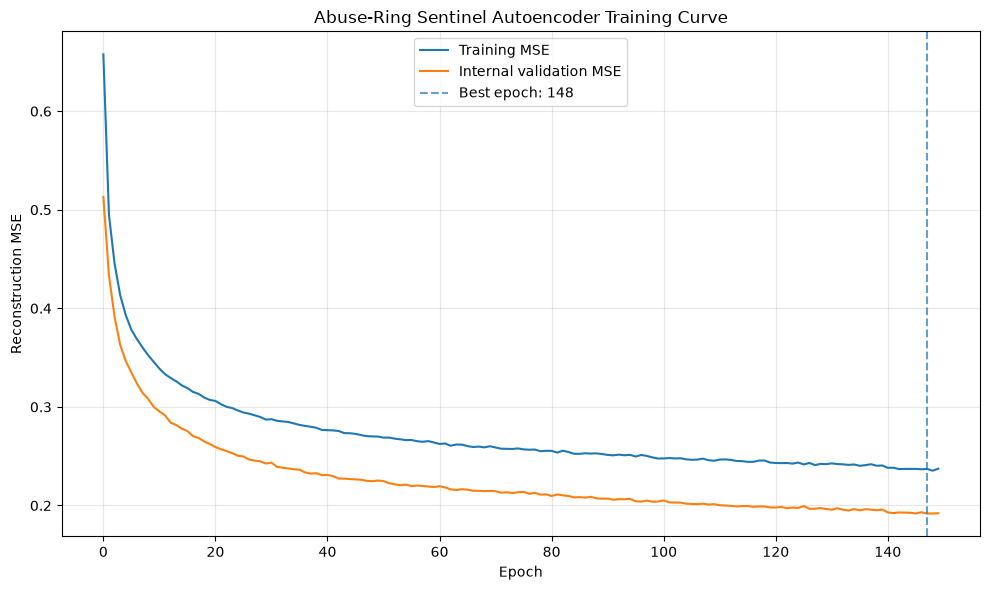

Saved: 03_autoencoder_training_curve.png


In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    history['train_loss'],
    label='Training MSE'
)

plt.plot(
    history['validation_loss'],
    label='Internal validation MSE'
)

plt.axvline(
    best_epoch - 1,
    linestyle='--',
    alpha=0.7,
    label=f'Best epoch: {best_epoch}'
)

plt.xlabel('Epoch')
plt.ylabel('Reconstruction MSE')

plt.title(
    'Abuse-Ring Sentinel Autoencoder Training Curve'
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    AE_TRAINING_CURVE_PATH,
    dpi=120
)

plt.show()

plt.close()

print(
    f"Saved: {AE_TRAINING_CURVE_PATH}"
)

In [34]:
def build_numerical_matrix(df):
    transformed = add_temporal_features(
        df
    )

    matrix = transformed[
        numerical_features
    ].copy()

    matrix = matrix.fillna(
        imputation_medians
    )

    matrix = matrix.clip(
        lower=lower_clip,
        upper=upper_clip,
        axis=1
    )

    if not np.isfinite(
        matrix.to_numpy(dtype=np.float64)
    ).all():
        raise ValueError(
            'Non-finite values detected after M5 preprocessing.'
        )

    return matrix


def reconstruction_mse(
    model,
    X_matrix
):
    X_scaled = scaler.transform(
        X_matrix
    ).astype(np.float32)

    if not np.isfinite(
        X_scaled
    ).all():
        raise ValueError(
            'Non-finite values detected after M5 scaling.'
        )

    tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        reconstructed = model(
            tensor
        )

        mse = torch.mean(
            (tensor - reconstructed) ** 2,
            dim=1
        ).cpu().numpy()

    if not np.isfinite(
        mse
    ).all():
        raise ValueError(
            'Non-finite reconstruction errors detected.'
        )

    return mse


calib_matrix = build_numerical_matrix(
    calib_df
)

calib_mse = reconstruction_mse(
    model,
    calib_matrix
)

calib_labels = (
    calib_df['isFraud']
    .astype(np.int8)
    .to_numpy()
)

calib_legit_mask = (
    calib_labels == 0
)

calib_fraud_mask = (
    calib_labels == 1
)

if not calib_legit_mask.any():
    raise ValueError(
        'M5 contains no legitimate transactions for threshold calibration.'
    )

if not calib_fraud_mask.any():
    raise ValueError(
        'M5 contains no fraudulent transactions for evaluation.'
    )

anomaly_threshold = float(
    np.percentile(
        calib_mse[calib_legit_mask],
        ANOMALY_THRESHOLD_PERCENTILE
    )
)

print("M5 Reconstruction Error")

print(
    f"Legit mean:   "
    f"{calib_mse[calib_legit_mask].mean():.6f}"
)

print(
    f"Legit median: "
    f"{np.median(calib_mse[calib_legit_mask]):.6f}"
)

print(
    f"Fraud mean:   "
    f"{calib_mse[calib_fraud_mask].mean():.6f}"
)

print(
    f"Fraud median: "
    f"{np.median(calib_mse[calib_fraud_mask]):.6f}"
)

print(
    f"M5-legit anomaly threshold: "
    f"{anomaly_threshold:.6f}"
)

M5 Reconstruction Error
Legit mean:   0.195867
Legit median: 0.097548
Fraud mean:   0.705907
Fraud median: 0.406509
M5-legit anomaly threshold: 0.723460


In [35]:
phase2_report = json.load(
    open(
        POLICY_PATH,
        'r',
        encoding='utf-8'
    )
)

threshold_block = phase2_report.get(
    'deployment_thresholds',
    {}
)

if 'auto_approve_max_risk' in threshold_block:
    t_low = float(
        threshold_block['auto_approve_max_risk']
    )
    t_high = float(
        threshold_block['auto_block_min_risk']
    )

elif 'manual_review_min_risk' in threshold_block:
    t_low = float(
        threshold_block['manual_review_min_risk']
    )
    t_high = float(
        threshold_block['manual_review_max_risk']
    )

else:
    raise KeyError(
        'Phase 2 policy does not contain recognizable deployment thresholds.'
    )

if 'calib_labels' not in globals():
    calib_labels = (
        calib_df['isFraud']
        .astype(np.int8)
        .to_numpy()
    )

if 'calib_mse' not in globals():
    raise NameError(
        'calib_mse is not available. Run the M5 reconstruction cell first.'
    )

m5_band_mask = (
    (probabilities >= t_low)
    &
    (probabilities <= t_high)
)

band_labels = calib_labels[
    m5_band_mask
]

band_mse = calib_mse[
    m5_band_mask
]

print(
    f"Phase 2 review band: "
    f"[{t_low:.6f}, {t_high:.6f}]"
)

print(
    f"M5 transactions in review band: "
    f"{int(m5_band_mask.sum()):,}"
)

if m5_band_mask.sum() == 0:

    band_pr_auc = None
    band_roc_auc = None

    print(
        'No M5 transactions fall inside the review band.'
    )

elif (
    band_labels.sum() == 0
    or
    (band_labels == 0).sum() == 0
):

    band_pr_auc = None
    band_roc_auc = None

    print(
        'M5 review band does not contain both classes; '
        'threshold-free lift is undefined.'
    )

else:

    band_pr_auc = average_precision_score(
        band_labels,
        band_mse
    )

    band_roc_auc = roc_auc_score(
        band_labels,
        band_mse
    )

    print(
        f"Review-band fraud rate: "
        f"{band_labels.mean() * 100:.2f}%"
    )

    print(
        f"Review-band MSE PR-AUC: "
        f"{band_pr_auc:.6f}"
    )

    print(
        f"Review-band MSE ROC-AUC: "
        f"{band_roc_auc:.6f}"
    )

Phase 2 review band: [0.210000, 0.520000]
M5 transactions in review band: 2,310
Review-band fraud rate: 5.93%
Review-band MSE PR-AUC: 0.101313
Review-band MSE ROC-AUC: 0.646199


In [38]:
sweep_rows = []

if 'band_labels' not in globals():
    band_labels = calib_labels[m5_band_mask]

if 'band_mse' not in globals():
    band_mse = calib_mse[m5_band_mask]

for percentile in [80, 85, 90, 95, 97, 99]:

    threshold = float(
        np.percentile(
            calib_mse[calib_legit_mask],
            percentile
        )
    )

    if len(band_mse):
        flagged = band_mse > threshold
    else:
        flagged = np.array(
            [],
            dtype=bool
        )

    if (
        flagged.sum() > 0
        and
        band_labels.sum() > 0
    ):

        precision = precision_score(
            band_labels,
            flagged,
            zero_division=0
        )

        recall = recall_score(
            band_labels,
            flagged,
            zero_division=0
        )

    else:

        precision = np.nan
        recall = 0.0

    sweep_rows.append({
        'legit_percentile': percentile,
        'mse_threshold': threshold,
        'band_flagged_count': int(
            flagged.sum()
        ),
        'band_flagged_pct': (
            float(flagged.mean() * 100)
            if len(flagged)
            else 0.0
        ),
        'precision': (
            None
            if pd.isna(precision)
            else float(precision)
        ),
        'recall': float(
            recall
        )
    })

sweep_df = pd.DataFrame(
    sweep_rows
)

print(
    sweep_df.to_string(
        index=False
    )
)

print(
    f"\nProduction threshold remains fixed at the pre-declared "
    f"{ANOMALY_THRESHOLD_PERCENTILE}th legitimate percentile."
)

 legit_percentile  mse_threshold  band_flagged_count  band_flagged_pct  precision   recall
               80       0.275687                 855         37.012987   0.092398 0.576642
               85       0.343055                 707         30.606061   0.086280 0.445255
               90       0.452848                 522         22.597403   0.091954 0.350365
               95       0.723460                 300         12.987013   0.103333 0.226277
               97       0.945119                 186          8.051948   0.096774 0.131387
               99       1.458336                  65          2.813853   0.153846 0.072993

Production threshold remains fixed at the pre-declared 95th legitimate percentile.


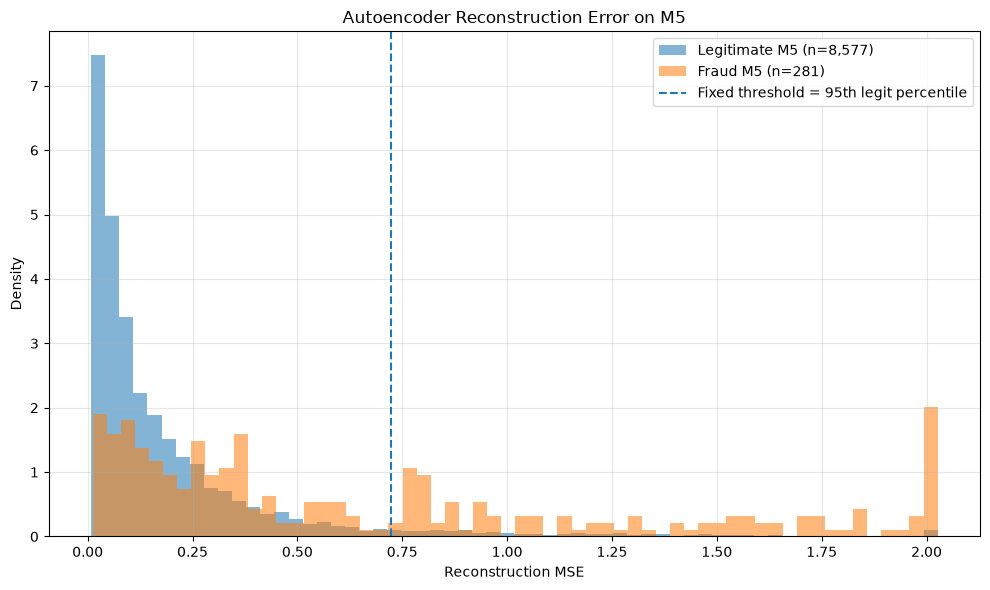

Saved: 04_autoencoder_mse_distribution.png


In [39]:
plt.figure(figsize=(10, 6))

clip_upper = np.percentile(
    calib_mse,
    99.5
)

plt.hist(
    np.clip(
        calib_mse[calib_legit_mask],
        0,
        clip_upper
    ),
    bins=60,
    alpha=0.55,
    density=True,
    label=f'Legitimate M5 (n={int(calib_legit_mask.sum()):,})'
)

if calib_fraud_mask.any():
    plt.hist(
        np.clip(
            calib_mse[calib_fraud_mask],
            0,
            clip_upper
        ),
        bins=60,
        alpha=0.55,
        density=True,
        label=f'Fraud M5 (n={int(calib_fraud_mask.sum()):,})'
    )

plt.axvline(
    anomaly_threshold,
    linestyle='--',
    label=(
        f'Fixed threshold = '
        f'{ANOMALY_THRESHOLD_PERCENTILE}th legit percentile'
    )
)

plt.xlabel('Reconstruction MSE')
plt.ylabel('Density')
plt.title('Autoencoder Reconstruction Error on M5')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    AE_MSE_DISTRIBUTION_PATH,
    dpi=120
)
plt.show()
plt.close()

print(f"Saved: {AE_MSE_DISTRIBUTION_PATH}")

In [40]:
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'input_dim': input_dimension,
        'hidden_dims': list(HIDDEN_DIMS),
        'latent_dim': LATENT_DIM,
        'dropout_p': DROPOUT_P
    },
    AE_MODEL_PATH
)

ae_artifacts = {
    'model_path': AE_MODEL_PATH,

    'numerical_features': numerical_features,

    'imputation_medians': (
        imputation_medians.to_dict()
    ),

    'lower_clip': (
        lower_clip.to_dict()
    ),

    'upper_clip': (
        upper_clip.to_dict()
    ),

    'scaler': scaler,

    'clip_lower_percentile': (
        CLIP_LOWER_PERCENTILE
    ),

    'clip_upper_percentile': (
        CLIP_UPPER_PERCENTILE
    ),

    'anomaly_threshold': (
        float(anomaly_threshold)
    ),

    'anomaly_threshold_percentile': (
        ANOMALY_THRESHOLD_PERCENTILE
    ),

    'threshold_calibration_dataset': (
        'M5 legitimate transactions'
    ),

    'phase2_t_low': (
        float(t_low)
    ),

    'phase2_t_high': (
        float(t_high)
    ),

    'input_dim': input_dimension,

    'hidden_dims': list(
        HIDDEN_DIMS
    ),

    'latent_dim': LATENT_DIM,

    'dropout_p': DROPOUT_P,

    'best_epoch': int(
        best_epoch
    ),

    'best_internal_validation_mse': (
        float(best_val_loss)
    ),

    'band_pr_auc_m5': (
        float(band_pr_auc)
        if band_pr_auc is not None
        else None
    ),

    'band_roc_auc_m5': (
        float(band_roc_auc)
        if band_roc_auc is not None
        else None
    )
}

joblib.dump(
    ae_artifacts,
    AE_ARTIFACT_PATH
)

band_report = {
    'phase2_review_band': {
        't_low': float(t_low),
        't_high': float(t_high)
    },

    'm5_review_band_rows': int(
        m5_band_mask.sum()
    ),

    'm5_review_band_fraud_rate': (
        float(band_labels.mean())
        if len(band_labels)
        else None
    ),

    'm5_band_pr_auc': (
        float(band_pr_auc)
        if band_pr_auc is not None
        else None
    ),

    'm5_band_roc_auc': (
        float(band_roc_auc)
        if band_roc_auc is not None
        else None
    ),

    'anomaly_threshold': (
        float(anomaly_threshold)
    ),

    'anomaly_threshold_percentile': (
        ANOMALY_THRESHOLD_PERCENTILE
    ),

    'threshold_sweep': sweep_rows
}

with open(
    AE_BAND_EVAL_PATH,
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        band_report,
        f,
        indent=4
    )

print(
    f"Model weights saved to: "
    f"{AE_MODEL_PATH}"
)

print(
    f"AE artifacts saved to: "
    f"{AE_ARTIFACT_PATH}"
)

print(
    f"Band evaluation saved to: "
    f"{AE_BAND_EVAL_PATH}"
)

Model weights saved to: abuse_ring_sentinel_autoencoder.pth
AE artifacts saved to: abuse_ring_sentinel_artifacts.pkl
Band evaluation saved to: autoencoder_band_evaluation.json


In [42]:
def load_abuse_ring_sentinel(
    model_path=AE_MODEL_PATH,
    artifact_path=AE_ARTIFACT_PATH,
    device_override=None
):
    device_used = (
        device_override
        if device_override is not None
        else device
    )

    artifacts = joblib.load(
        artifact_path
    )

    checkpoint = torch.load(
        model_path,
        map_location=device_used,
        weights_only=False
    )

    loaded_model = FraudDetector(
        input_dim=artifacts['input_dim'],
        hidden_dims=tuple(artifacts['hidden_dims']),
        latent_dim=artifacts['latent_dim'],
        dropout_p=artifacts['dropout_p']
    ).to(device_used)

    loaded_model.load_state_dict(
        checkpoint['model_state_dict']
    )

    loaded_model.eval()

    return loaded_model, artifacts


def score_transactions_for_anomaly(
    raw_df,
    loaded_model,
    ae_artifacts,
    device_override=None
):
    device_used = (
        device_override
        if device_override is not None
        else device
    )

    numerical = ae_artifacts['numerical_features']
    medians = pd.Series(
        ae_artifacts['imputation_medians']
    )
    saved_scaler = ae_artifacts['scaler']
    threshold = float(
        ae_artifacts['anomaly_threshold']
    )

    transformed = (
        add_temporal_features(raw_df)
        if 'TransactionDT' in raw_df.columns
        else raw_df.copy()
    )

    X = transformed[numerical].copy()
    X = X.fillna(medians)

    X_scaled = saved_scaler.transform(
        X
    ).astype(np.float32)

    tensor = torch.tensor(
        X_scaled,
        dtype=torch.float32,
        device=device_used
    )

    loaded_model.eval()

    with torch.no_grad():
        reconstructed = loaded_model(tensor)
        mse = torch.mean(
            (tensor - reconstructed) ** 2,
            dim=1
        ).cpu().numpy()

    return pd.DataFrame({
        'reconstruction_mse': mse,
        'zero_day_flag': mse > threshold
    }, index=raw_df.index)


frozen_model, frozen_artifacts = load_abuse_ring_sentinel()

smoke = score_transactions_for_anomaly(
    calib_df.head(5),
    frozen_model,
    frozen_artifacts
)

print(smoke)

   reconstruction_mse  zero_day_flag
0            0.356622          False
1            0.130133          False
2            0.197200          False
3            0.129448          False
4            0.252663          False


In [43]:
phase3_handoff = {
    "phase": "Phase 3",
    "component": "Unsupervised Autoencoder Anomaly Detector",

    "training": {
        "training_dataset": "M1-M4 legitimate transactions",
        "internal_validation_fraction": float(
            INTERNAL_VAL_FRACTION
        ),
        "best_epoch": int(
            best_epoch
        ),
        "best_validation_mse": float(
            best_val_loss
        )
    },

    "preprocessing": {
        "imputation": "M1-M4 legitimate medians",
        "lower_clip_percentile": float(
            CLIP_LOWER_PERCENTILE
        ),
        "upper_clip_percentile": float(
            CLIP_UPPER_PERCENTILE
        ),
        "scaler": "StandardScaler"
    },

    "anomaly_detection": {
        "threshold": float(
            anomaly_threshold
        ),
        "threshold_percentile": int(
            ANOMALY_THRESHOLD_PERCENTILE
        ),
        "threshold_calibration_dataset": (
            "M5 legitimate transactions"
        )
    },

    "phase2_review_band": {
        "t_low": float(
            t_low
        ),
        "t_high": float(
            t_high
        ),
        "m5_transactions": int(
            m5_band_mask.sum()
        ),
        "m5_fraud_rate": float(
            band_labels.mean()
        ),
        "m5_mse_pr_auc": (
            float(band_pr_auc)
            if band_pr_auc is not None
            else None
        ),
        "m5_mse_roc_auc": (
            float(band_roc_auc)
            if band_roc_auc is not None
            else None
        )
    },

    "operating_point": {
        "flagged_review_band_pct": float(
            sweep_df.loc[
                sweep_df['legit_percentile']
                == ANOMALY_THRESHOLD_PERCENTILE,
                'band_flagged_pct'
            ].iloc[0]
        ),
        "precision": float(
            sweep_df.loc[
                sweep_df['legit_percentile']
                == ANOMALY_THRESHOLD_PERCENTILE,
                'precision'
            ].iloc[0]
        ),
        "recall": float(
            sweep_df.loc[
                sweep_df['legit_percentile']
                == ANOMALY_THRESHOLD_PERCENTILE,
                'recall'
            ].iloc[0]
        )
    },

    "deployment_role": (
        "Auxiliary anomaly signal inside the Phase 2 "
        "ambiguous review band. Not an autonomous blocking rule."
    ),

    "m6_status": "LOCKED_NOT_USED_IN_PHASE_3",

    "artifacts": {
        "model": AE_MODEL_PATH,
        "preprocessing": AE_ARTIFACT_PATH,
        "band_evaluation": AE_BAND_EVAL_PATH,
        "training_curve": AE_TRAINING_CURVE_PATH,
        "mse_distribution": AE_MSE_DISTRIBUTION_PATH
    }
}

print(
    json.dumps(
        phase3_handoff,
        indent=4
    )
)

print("PHASE 3 COMPLETE: AUTOENCODER FROZEN")

{
    "phase": "Phase 3",
    "component": "Unsupervised Autoencoder Anomaly Detector",
    "training": {
        "training_dataset": "M1-M4 legitimate transactions",
        "internal_validation_fraction": 0.15,
        "best_epoch": 148,
        "best_validation_mse": 0.19183301428953806
    },
    "preprocessing": {
        "imputation": "M1-M4 legitimate medians",
        "lower_clip_percentile": 0.01,
        "upper_clip_percentile": 0.99,
        "scaler": "StandardScaler"
    },
    "anomaly_detection": {
        "threshold": 0.7234599590301514,
        "threshold_percentile": 95,
        "threshold_calibration_dataset": "M5 legitimate transactions"
    },
    "phase2_review_band": {
        "t_low": 0.20999999344348907,
        "t_high": 0.5199999809265137,
        "m5_transactions": 2310,
        "m5_fraud_rate": 0.05930735930735931,
        "m5_mse_pr_auc": 0.10131275996874282,
        "m5_mse_roc_auc": 0.6461987027252175
    },
    "operating_point": {
        "flagged_revie